# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** **Pengolahan Citra**  
**Nama:** **Dhiya Maharanni**  
**NIM:** **122400019**  
https://github.com/dhiya013/Pengolahan_Multimedia.git

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


### **Jawab Soal 1:**

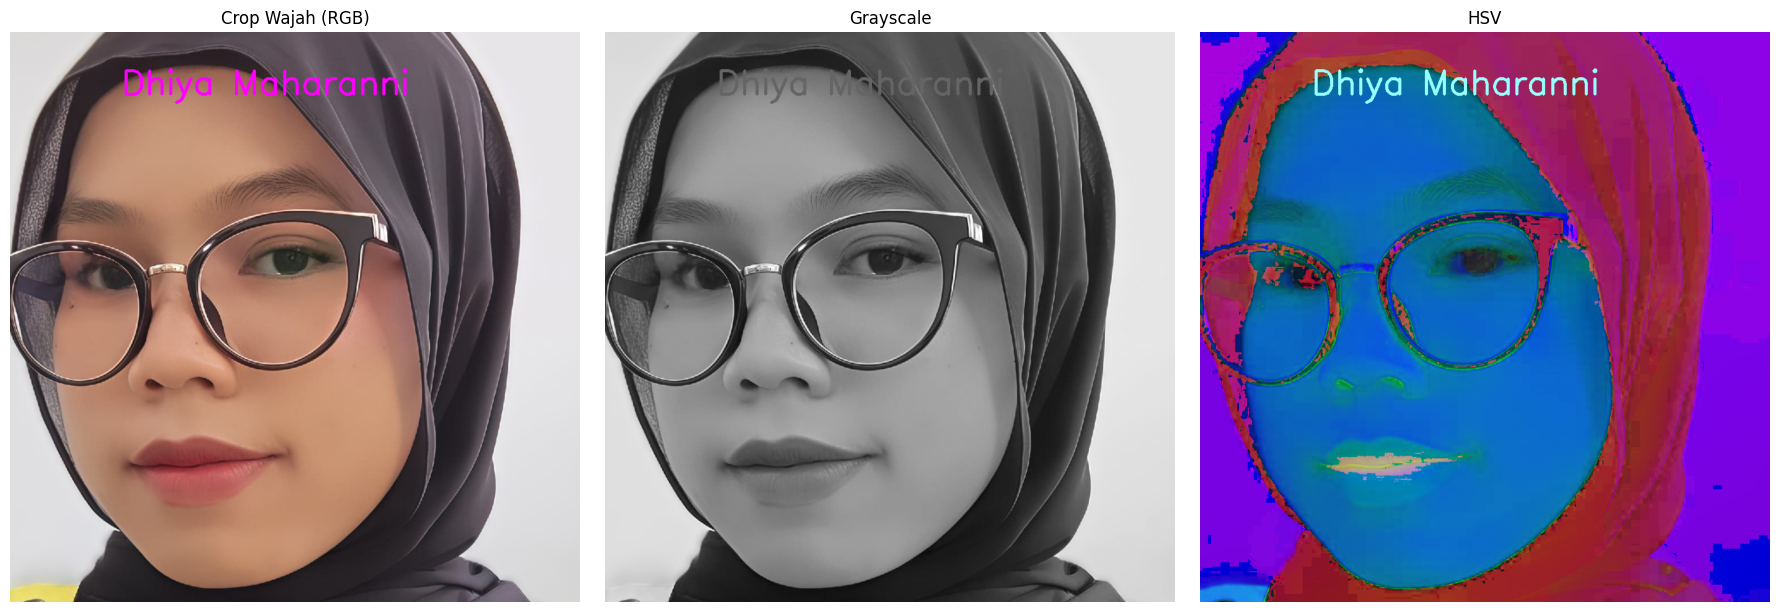

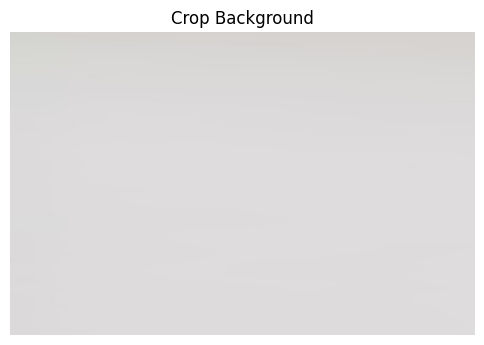

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = os.path.join('data', 'saya.jpg')
img = cv2.imread(image_path)

if img is None:
    print("Error: Gambar tidak ditemukan")
    exit()

face_crop = img[350:1350, 300:1300]
bg_crop = img[100:1000, 0:180]
face_resized = cv2.resize(face_crop, (920, 920))
bg_resized = cv2.resize(bg_crop, (920, 600))

cv2.putText(
    face_resized,
    "Dhiya Maharanni",
    (180, 100),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.8,
    (255, 0, 255),
    4
)

gray = cv2.cvtColor(face_resized, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(face_resized, cv2.COLOR_BGR2HSV)
face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(face_rgb)
axes[0].set_title("Crop Wajah (RGB)")
axes[0].axis("off")

axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(hsv)
axes[2].set_title("HSV")
axes[2].axis("off")

plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(bg_resized, cv2.COLOR_BGR2RGB))
plt.title("Crop Background")
plt.axis("off")
plt.show()

## Analisis Hasil

    Pada percobaan ini dilakukan proses cropping pada gambar selfie untuk mengambil area tertentu dari citra asli. Cropping persegi digunakan pada area wajah agar fokus analisis tertuju pada objek utama, yaitu wajah. Sementara itu, cropping persegi panjang digunakan pada area latar belakang untuk menunjukkan bagian citra yang tidak mengandung objek utama.
    Setelah proses cropping, ukuran gambar diubah menjadi 920 × 920 piksel untuk area wajah dan ukuran persegi panjang untuk area latar belakang agar visualisasi menjadi lebih seragam dan mudah diamati.
    Konversi grayscale mengubah gambar berwarna menjadi citra abu-abu dengan hanya mempertahankan informasi intensitas cahaya. Pada hasil grayscale, detail bentuk wajah masih terlihat dengan jelas, tetapi informasi warna seperti warna kulit, hijab, dan latar belakang tidak lagi terlihat.
    Konversi HSV mengubah representasi warna dari format RGB ke Hue, Saturation, dan Value. Pada mode ini, informasi warna dipisahkan berdasarkan komponen warna, tingkat kejenuhan, dan tingkat kecerahan, sehingga lebih memudahkan analisis warna dibandingkan format RGB.Penambahan teks nama di atas kepala berfungsi sebagai anotasi identitas pada citra hasil cropping.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


### **Jawab Soal 2:**

Shape img2_rgb: (920, 920, 3)
Tinggi gambar: 920 piksel
Lebar gambar: 920 piksel
Jumlah channel: 3 (RGB)


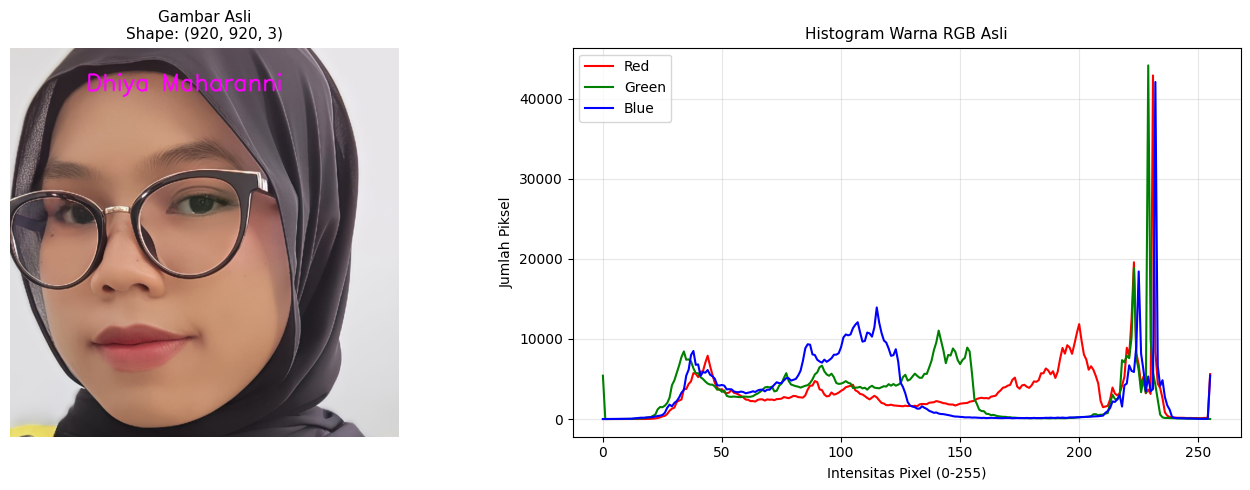

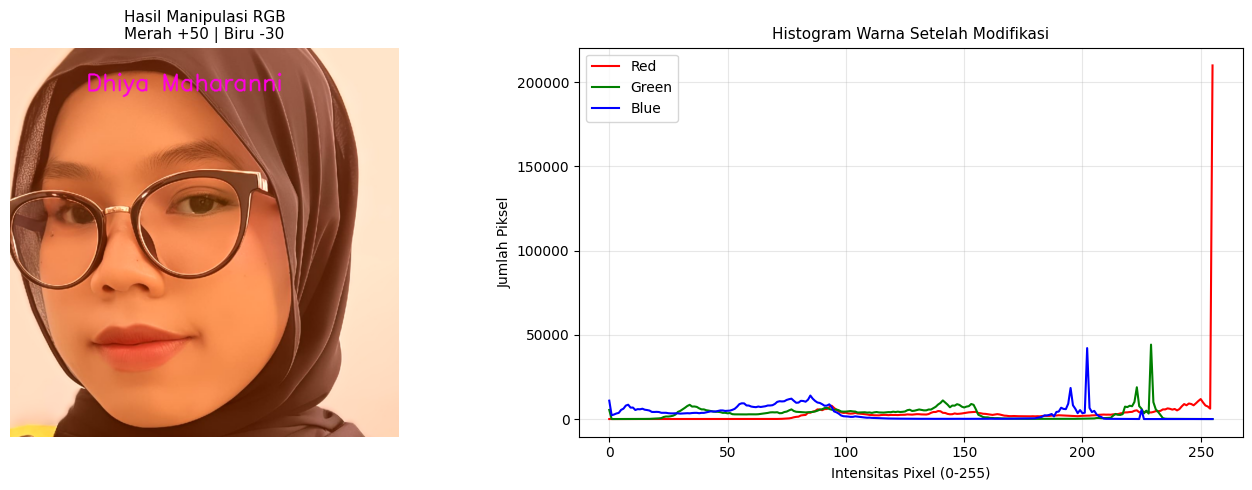

True


In [4]:
img2_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)

print("Shape img2_rgb:", img2_rgb.shape)
print("Tinggi gambar:", img2_rgb.shape[0], "piksel")
print("Lebar gambar:", img2_rgb.shape[1], "piksel")
print("Jumlah channel:", img2_rgb.shape[2], "(RGB)")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].imshow(img2_rgb)
axs[0].set_title(f"Gambar Asli\nShape: {img2_rgb.shape}", fontsize=11)
axs[0].axis('off')

colors = ('r', 'g', 'b')
labels = ('Red', 'Green', 'Blue')

for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_rgb], [i], None, [256], [0, 256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna RGB Asli", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

img2_mod = img2_rgb.astype(np.int16)
img2_mod[:, :, 0] = np.clip(img2_mod[:, :, 0] + 50, 0, 255)
img2_mod[:, :, 2] = np.clip(img2_mod[:, :, 2] - 30, 0, 255)
img2_mod = img2_mod.astype(np.uint8)
cv2.imwrite("rgb_modified.png", cv2.cvtColor(img2_mod, cv2.COLOR_RGB2BGR))
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].imshow(img2_mod)
axs[0].set_title("Hasil Manipulasi RGB\nMerah +50 | Biru -30", fontsize=11)
axs[0].axis('off')
for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img2_mod], [i], None, [256], [0, 256])
    axs[1].plot(hist, color=col, label=label)

axs[1].set_title("Histogram Warna Setelah Modifikasi", fontsize=11)
axs[1].set_xlabel("Intensitas Pixel (0-255)")
axs[1].set_ylabel("Jumlah Piksel")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(np.array_equal(img2_rgb[:, :, 1], img2_mod[:, :, 1]))

## Analisis Hasil

      Pada percobaan ini dilakukan manipulasi channel warna RGB pada gambar hasil cropping wajah dari soal sebelumnya. Proses manipulasi dilakukan dengan menaikkan intensitas channel merah sebesar 50 poin dan menurunkan intensitas channel biru sebesar 30 poin, dengan pembatasan nilai piksel menggunakan `numpy.clip()` agar tetap berada pada rentang 0 sampai 255.
      Berdasarkan hasil visualisasi, gambar setelah modifikasi menunjukkan perubahan warna yang lebih hangat dibandingkan gambar asli. Warna kulit terlihat lebih oranye atau kemerahan karena peningkatan intensitas channel merah. Sementara itu, penurunan channel biru menyebabkan warna dingin pada gambar berkurang, sehingga background yang awalnya putih cenderung berubah menjadi krem. Histogram RGB gambar asli menunjukkan distribusi intensitas warna yang masih relatif seimbang, meskipun masing-masing channel memiliki pola distribusi yang berbeda sesuai komposisi warna pada gambar. Pada histogram hasil modifikasi, channel merah mengalami pergeseran ke arah kanan karena peningkatan intensitas warna merah. Hal ini menunjukkan bahwa banyak piksel memiliki nilai merah yang lebih tinggi dibandingkan gambar asli. Channel biru mengalami penurunan distribusi karena intensitas biru dikurangi sebesar 30 poin. Channel hijau relatif tetap karena tidak dilakukan manipulasi pada channel tersebut. Percobaan ini menunjukkan bahwa perubahan kecil pada channel RGB dapat memberikan perubahan visual yang cukup signifikan terhadap karakter warna suatu citra.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


### **Jawab Soal 3:**

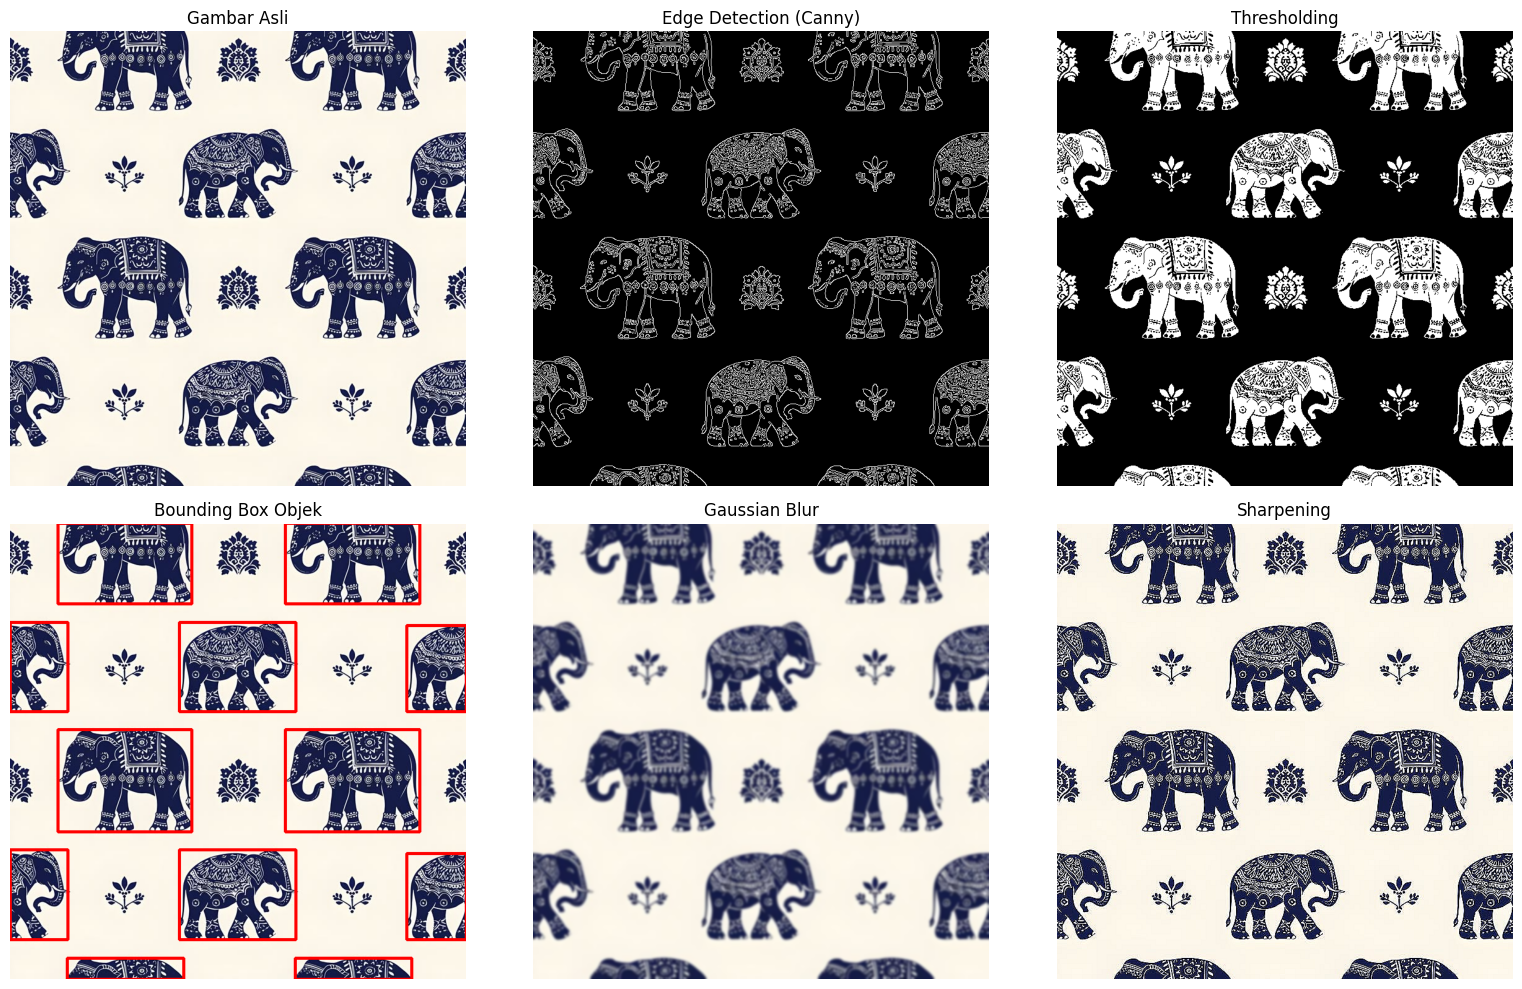

True

In [9]:
image_path = os.path.join('data', 'batik.jpg')
img = cv2.imread(image_path)
if img is None:
    print("Error: Gambar tidak ditemukan")
    exit()
    
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_box = img_rgb.copy()
for contour in contours:
    area = cv2.contourArea(contour)
    if area > 3000:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_box,(x, y), (x + w, y + h), (255, 0, 0),3)
blur = cv2.GaussianBlur(img_rgb, (11, 11), 0)

kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharp = cv2.filter2D(img_rgb, -1, kernel_sharp)
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title("Gambar Asli")
axs[0, 0].axis("off")

axs[0, 1].imshow(edges, cmap='gray')
axs[0, 1].set_title("Edge Detection (Canny)")
axs[0, 1].axis("off")

axs[0, 2].imshow(thresh, cmap='gray')
axs[0, 2].set_title("Thresholding")
axs[0, 2].axis("off")

axs[1, 0].imshow(img_box)
axs[1, 0].set_title("Bounding Box Objek")
axs[1, 0].axis("off")

axs[1, 1].imshow(blur)
axs[1, 1].set_title("Gaussian Blur")
axs[1, 1].axis("off")

axs[1, 2].imshow(sharp)
axs[1, 2].set_title("Sharpening")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()
cv2.imwrite("data/hasil_edges.png", edges)
cv2.imwrite("data/hasil_threshold.png", thresh)
cv2.imwrite("data/hasil_bounding_box.png", cv2.cvtColor(img_box, cv2.COLOR_RGB2BGR))
cv2.imwrite("data/hasil_blur.png", cv2.cvtColor(blur, cv2.COLOR_RGB2BGR))
cv2.imwrite("data/hasil_sharp.png", cv2.cvtColor(sharp, cv2.COLOR_RGB2BGR))

## Analisis Hasil

       Pada percobaan ini digunakan gambar kain batik bermotif gajah dengan background bertekstur berupa pola berulang. Karena gambar memiliki banyak detail ornamen dan kontras warna yang cukup jelas antara motif berwarna biru tua dan background berwarna terang, teknik pengolahan citra dapat menunjukkan hasil yang cukup baik. Hasil edge detection menggunakan metode Canny menunjukkan garis tepi yang jelas pada setiap motif gajah maupun ornamen kecil di sekitarnya. Kontur tubuh gajah, telinga, kaki, serta pola ukiran pada tubuh gajah ikut terdeteksi karena adanya perubahan intensitas piksel yang signifikan. Namun, karena background juga memiliki tekstur berulang, metode ini tidak hanya mendeteksi objek utama, tetapi juga menangkap detail dekoratif lain sehingga hasil edge terlihat cukup padat.
       Pada proses thresholding, citra grayscale diubah menjadi citra biner menggunakan nilai ambang tertentu sehingga objek bermotif gajah berubah menjadi area putih dan background menjadi hitam. Karena kontras antara motif dan background cukup tinggi, proses segmentasi berhasil memisahkan objek dengan cukup jelas. Meskipun demikian, karena gambar terdiri dari pola berulang, thresholding juga mempertahankan semua motif gajah lain, bukan hanya satu objek utama. Bounding box dibuat secara otomatis menggunakan contour detection. Sistem mendeteksi setiap contour dengan luas area tertentu, sehingga sebagian besar motif gajah berhasil diberi kotak pembatas. Hasil ini menunjukkan segmentasi berjalan dengan baik untuk objek yang utuh. Namun, beberapa motif gajah yang terpotong di tepi gambar juga tetap terdeteksi karena sebagian contour masih memenuhi batas luas minimum yang telah ditentukan.
       Filter Gaussian Blur menghasilkan gambar yang terlihat lebih halus dibandingkan gambar asli. Detail-detail kecil seperti motif ukiran pada tubuh gajah menjadi kurang tajam, dan garis tepi terlihat lebih lembut. Efek ini menunjukkan bahwa blur efektif untuk mengurangi noise dan detail halus, tetapi dapat mengurangi ketajaman informasi visual. Sebaliknya, filter sharpening meningkatkan ketajaman gambar sehingga detail ukiran pada motif gajah menjadi lebih tegas dan garis antar objek terlihat lebih jelas. Warna motif juga tampak lebih kontras dibandingkan gambar asli. Namun, karena sharpening memperkuat detail frekuensi tinggi, tekstur background juga menjadi lebih menonjol. Berdasarkan hasil percobaan, edge detection dan thresholding efektif untuk mendeteksi pola objek pada citra dengan kontras tinggi, sedangkan Gaussian Blur dan sharpening memberikan efek visual yang berlawanan, yaitu menghaluskan detail dan mempertajam detail.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

### **Jawab Soal 4:**

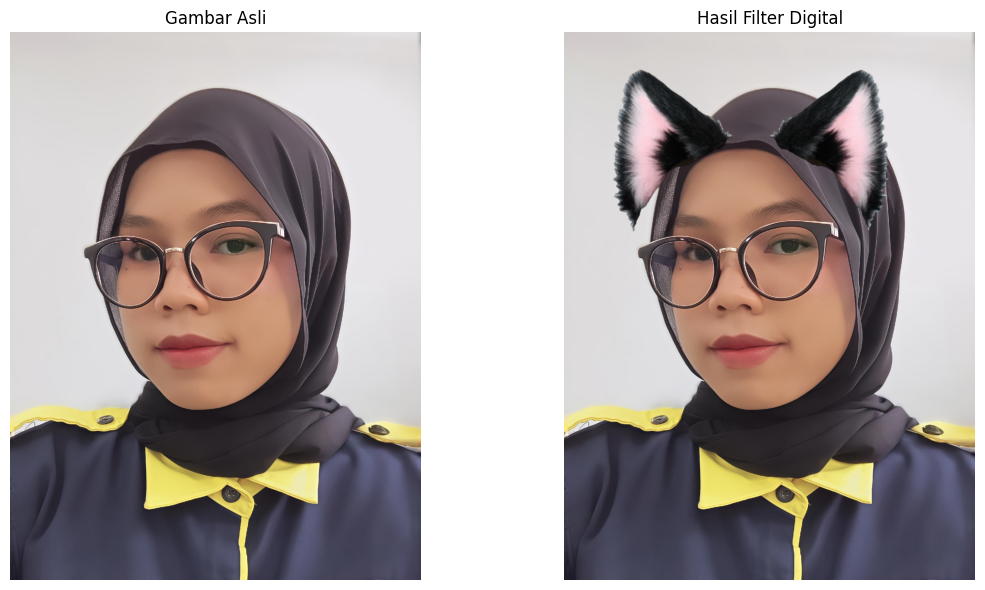

True

In [11]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = os.path.join('data', 'saya.jpg')
filter_path = os.path.join('data', 'cat.png')

img = cv2.imread(image_path)
overlay = cv2.imread(filter_path, cv2.IMREAD_UNCHANGED)

if img is None:
    print("Error: Gambar tidak ditemukan")
    exit()

if overlay is None:
    print("Error: Filter tidak ditemukan")
    exit()

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

result = img.copy()

faces = detector(img)

for face in faces:
    landmarks = predictor(img, face)

    # Lebar kepala
    left_face = np.array([
        landmarks.part(0).x,
        landmarks.part(0).y
    ])

    right_face = np.array([
        landmarks.part(16).x,
        landmarks.part(16).y
    ])

    forehead = np.array([
        landmarks.part(27).x,
        landmarks.part(27).y
    ])

    face_width = np.linalg.norm(right_face - left_face)

    overlay_width = int(face_width * 1.6)
    overlay_height = int(overlay_width * overlay.shape[0] / overlay.shape[1])

    x = int(forehead[0] - overlay_width / 2 + 70)
    y = int(forehead[1] - overlay_height * 2)

    overlay_resized = cv2.resize(overlay, (overlay_width, overlay_height))

    if overlay_resized.shape[2] == 4:
        overlay_rgb = overlay_resized[:, :, :3]
        alpha = overlay_resized[:, :, 3] / 255.0
    else:
        overlay_rgb = overlay_resized
        alpha = np.ones((overlay_height, overlay_width))

    if x < 0:
        x = 0

    if y < 0:
        y = 0

    if x + overlay_width > result.shape[1]:
        overlay_width = result.shape[1] - x
        overlay_rgb = overlay_rgb[:, :overlay_width]
        alpha = alpha[:, :overlay_width]

    if y + overlay_height > result.shape[0]:
        overlay_height = result.shape[0] - y
        overlay_rgb = overlay_rgb[:overlay_height]
        alpha = alpha[:overlay_height]

    roi = result[y:y+overlay_height, x:x+overlay_width]

    for c in range(3):
        roi[:, :, c] = (
            alpha * overlay_rgb[:, :, c] +
            (1 - alpha) * roi[:, :, c]
        )

    result[y:y+overlay_height, x:x+overlay_width] = roi

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(result_rgb)
axs[1].set_title("Hasil Filter Digital")
axs[1].axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite("data/hasil_filter_wajah.png", result)

## Analisis Hasil

       Pada percobaan ini dilakukan deteksi wajah menggunakan library Dlib dan model facial landmark 68 titik. Landmark digunakan untuk menentukan posisi wajah sehingga filter digital dapat ditempatkan secara otomatis mengikuti bentuk kepala pengguna. Filter digital yang digunakan berupa kuping kucing transparan (`cat.png`). Posisi overlay ditentukan berdasarkan titik sisi kiri wajah (`landmark 0`), sisi kanan wajah (`landmark 16`), dan titik tengah atas hidung (`landmark 27`). Jarak antara sisi kiri dan kanan wajah digunakan untuk menentukan ukuran filter agar proporsional terhadap ukuran kepala.
       Ukuran overlay diperbesar menggunakan skala `1.6` sehingga kuping terlihat lebih sesuai dengan bentuk kepala pada gambar. Posisi vertikal overlay juga dinaikkan ke bagian atas kepala agar filter tidak menutupi area mata dan wajah. Teknik alpha blending digunakan untuk menggabungkan gambar filter dengan gambar asli menggunakan alpha channel pada file PNG transparan. Teknik ini membuat bagian transparan filter tidak menutupi citra asli sehingga hasil terlihat lebih natural.
       Berdasarkan hasil visualisasi, filter kuping kucing berhasil ditempatkan di bagian atas kepala dengan cukup baik. Overlay mengikuti posisi kepala dan terlihat menyerupai filter digital pada media sosial. Penyesuaian ukuran dan posisi diperlukan karena bentuk kepala pada gambar dipengaruhi oleh penggunaan hijab sehingga posisi overlay perlu diatur secara manual agar tetap terlihat proporsional. Tantangan utama pada implementasi ini adalah menentukan ukuran overlay dan posisi vertikal yang tepat. Jika ukuran terlalu kecil, filter terlihat tidak sesuai dengan ukuran kepala. Sebaliknya, jika posisi terlalu rendah, overlay dapat menutupi wajah. Oleh karena itu, dilakukan penyesuaian parameter posisi dan skala hingga diperoleh hasil yang lebih sesuai.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

### **Jawab Soal 5:**

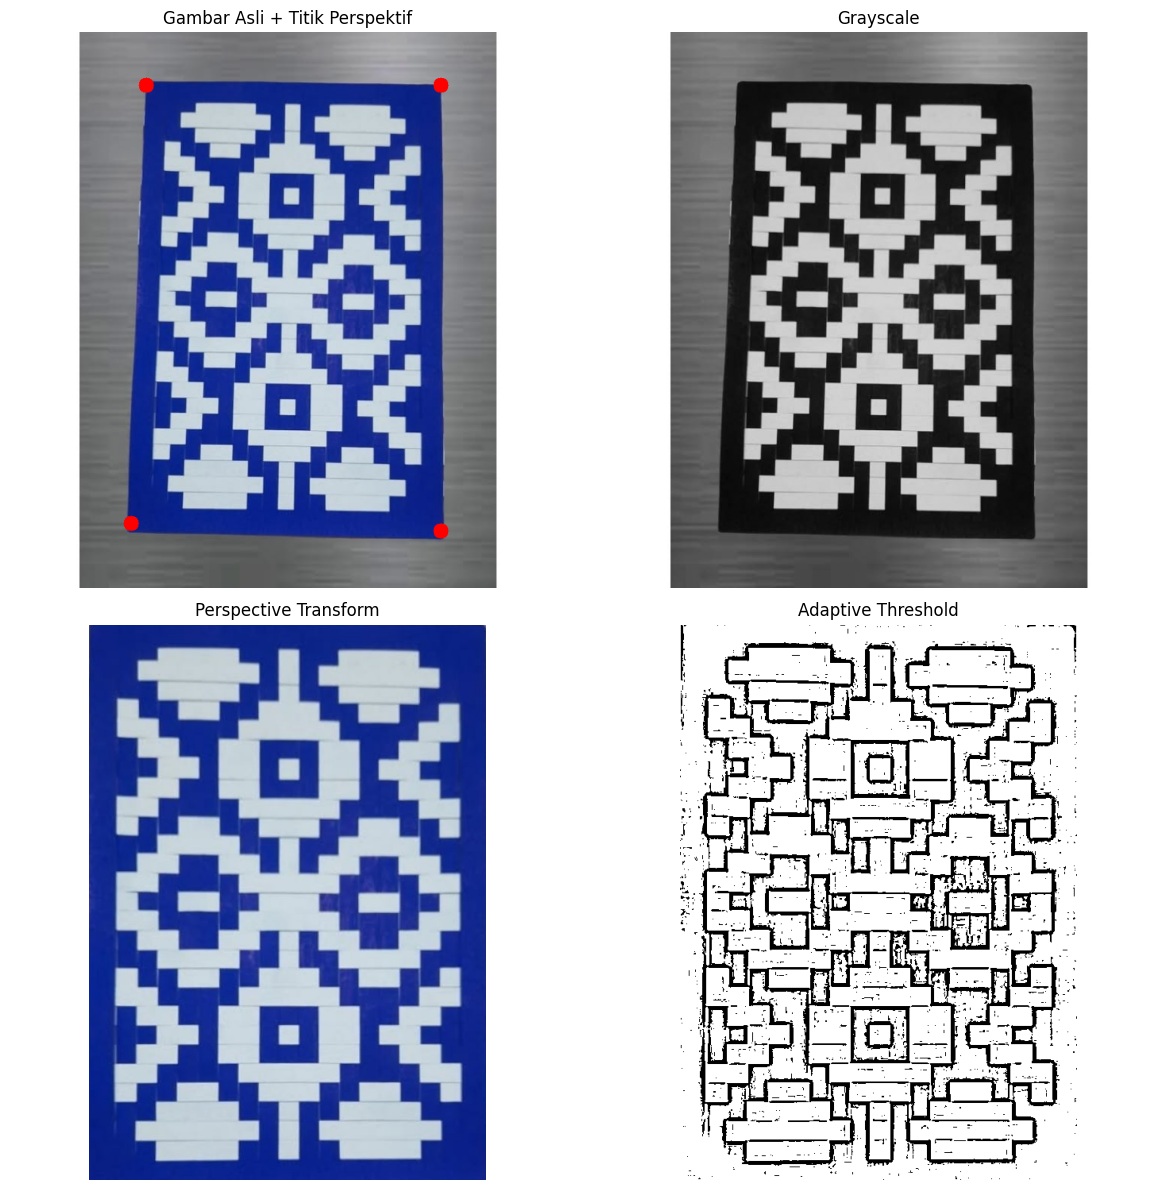

True

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Membaca gambar
image_path = os.path.join('data', 'kerajinan.jpg')
img = cv2.imread(image_path)

# Cek gambar
if img is None:
    print("Error: Gambar tidak ditemukan")
    exit()

# Konversi BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menentukan 4 titik manual pada sudut objek
pts1 = np.float32([
    [180, 70],    # kiri atas
    [570, 70],    # kanan atas
    [160, 650],   # kiri bawah
    [570, 660]    # kanan bawah
])

# Ukuran hasil transformasi
width = 500
height = 700

pts2 = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])

# Perspective transform
matrix = cv2.getPerspectiveTransform(pts1, pts2)

warped = cv2.warpPerspective(
    img_rgb,
    matrix,
    (width, height)
)

# Grayscale hasil transformasi
warped_gray = cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY)

# Adaptive Threshold
adaptive = cv2.adaptiveThreshold(
    warped_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Menampilkan titik perspective pada gambar asli
img_points = img_rgb.copy()

for point in pts1:
    x, y = point.astype(int)

    cv2.circle(
        img_points,
        (x, y),
        10,
        (255, 0, 0),
        -1
    )

# Visualisasi hasil
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0,0].imshow(img_points)
axs[0,0].set_title("Gambar Asli + Titik Perspektif")
axs[0,0].axis("off")

axs[0,1].imshow(gray, cmap='gray')
axs[0,1].set_title("Grayscale")
axs[0,1].axis("off")

axs[1,0].imshow(warped)
axs[1,0].set_title("Perspective Transform")
axs[1,0].axis("off")

axs[1,1].imshow(adaptive, cmap='gray')
axs[1,1].set_title("Adaptive Threshold")
axs[1,1].axis("off")

plt.tight_layout()
plt.show()

# Simpan hasil
cv2.imwrite(
    "data/hasil_perspective.png",
    cv2.cvtColor(warped, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "data/hasil_threshold.png",
    adaptive
)

## Analisis Hasil

       Pada percobaan ini digunakan gambar kerajinan anyaman kertas berwarna biru dan putih yang difoto dengan sudut pengambilan yang sedikit miring serta pencahayaan yang tidak merata. Untuk memperbaiki tampilan citra dilakukan beberapa tahap preprocessing, yaitu grayscale, perspective transform, dan adaptive thresholding. Tahap pertama adalah konversi citra RGB menjadi grayscale. Proses ini bertujuan untuk menyederhanakan informasi citra dengan mengubah gambar berwarna menjadi citra intensitas abu-abu sehingga proses pengolahan berikutnya menjadi lebih mudah dilakukan.
       Selanjutnya dilakukan perspective transform menggunakan empat titik manual yang ditentukan pada sudut objek anyaman. Teknik ini digunakan untuk memperbaiki distorsi perspektif akibat posisi kamera yang tidak sejajar dengan objek saat pengambilan gambar. Setelah transformasi dilakukan, bentuk objek terlihat lebih lurus, simetris, dan proporsional dibandingkan gambar asli. Pada tahap thresholding digunakan metode Adaptive Threshold Gaussian. Metode ini dipilih karena pencahayaan pada background meja tidak merata dan terdapat gradasi intensitas cahaya pada gambar. Adaptive threshold menghitung nilai threshold berdasarkan area lokal di sekitar piksel sehingga hasil segmentasi objek menjadi lebih jelas dibandingkan threshold global biasa.
       Hasil akhir menunjukkan pola anyaman putih dan biru terlihat lebih kontras serta lebih mudah dibedakan dari background. Perspective transform membantu memperbaiki bentuk objek, sedangkan adaptive threshold meningkatkan keterbacaan pola dan detail pada citra.

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.